# Problem 1: Correlation and Independence

**Problem Statement:** The random variable Z is distributed according to the standard normal distribution N(0, 1). Compute the correlation between Z and Z². Are the two variables independent? Discuss the result.

## Theoretical Solution

To find the correlation between Z and Z², we need to compute:

$$\text{Corr}(Z, Z^2) = \frac{\text{Cov}(Z, Z^2)}{\sqrt{\text{Var}(Z) \cdot \text{Var}(Z^2)}}$$

Where:
- $Z \sim N(0,1)$, so $E[Z] = 0$ and $\text{Var}(Z) = 1$
- $\text{Cov}(Z, Z^2) = E[Z \cdot Z^2] - E[Z] \cdot E[Z^2] = E[Z^3] - 0 \cdot E[Z^2] = E[Z^3]$

For a standard normal distribution, all odd moments are zero, so $E[Z^3] = 0$.

Therefore: $\text{Cov}(Z, Z^2) = 0$, which means $\text{Corr}(Z, Z^2) = 0$.

**However, zero correlation does not imply independence!**

## Conclusion

**Answer Summary:**

1. **Correlation between Z and Z²**: The correlation is **exactly 0**.
   - Mathematically: $\text{Corr}(Z, Z^2) = \frac{E[Z^3]}{1 \cdot \sqrt{2}} = \frac{0}{\sqrt{2}} = 0$
   - This is because $E[Z^3] = 0$ for the standard normal distribution (odd moments are zero).

2. **Independence**: Z and Z² are **NOT independent**.
   - **Deterministic relationship**: $Z^2 = |Z|^2$ - knowing Z completely determines Z²
   - **Conditional probabilities**: $P(Z^2 > t | Z = z) \neq P(Z^2 > t)$ for many values
   - **Joint distribution**: Concentrated on parabola $w = z^2$, not the product of marginals
   - **Information content**: Mutual information $I(Z; Z^2) > 0$

**Mathematical Proof of Non-Independence:**
The most direct proof is that Z² is a deterministic function of Z. For any specific value $z$, we have:
$$P(Z^2 = z^2 | Z = z) = 1 \neq P(Z^2 = z^2)$$
Since the conditional probability differs from the marginal probability, independence fails.

**Key Insight**: This demonstrates that **zero correlation ≠ independence**. Correlation only captures linear relationships, but Z and Z² have a perfect nonlinear (quadratic) relationship.

---

# Problem 2: Monte Carlo Pricing Analysis with Term Structures

## 1. Import Required Libraries

In [1]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.6.0-debug
pid: 13302


## 2. Create USD Yield Curve

In [2]:
# Define USD yield curve data
maturities = [1/12, 1/4, 1/2, 3/4, 1, 2, 3, 5]  # in years
spot_rates = [0.01, 0.02, 0.03, 0.035, 0.04, 0.0475, 0.0525, 0.06]  # as decimals

print("USD Yield Curve Data:")
print("Maturity\tSpot Rate")
for mat, rate in zip(maturities, spot_rates):
    print(f"{mat:.3f}\t\t{rate:.4f} ({rate*100:.2f}%)")

# Create the USD yield curve and store it in the market
usd_curve_handle = orf.ycCreate("USD", maturities, spot_rates, 0)  # 0 = SPOTRATE
print(f"\nUSD yield curve created with handle: {usd_curve_handle}")

USD Yield Curve Data:
Maturity	Spot Rate
0.083		0.0100 (1.00%)
0.250		0.0200 (2.00%)
0.500		0.0300 (3.00%)
0.750		0.0350 (3.50%)
1.000		0.0400 (4.00%)
2.000		0.0475 (4.75%)
3.000		0.0525 (5.25%)
5.000		0.0600 (6.00%)

USD yield curve created with handle: USD


## 3. Create VOLTS Volatility Term Structure

In [3]:
# Define VOLTS volatility term structure data
vol_maturities = [1/12, 1/4, 1/2, 3/4, 1, 2, 3]  # in years
vol_values = [0.25, 0.26, 0.27, 0.28, 0.30, 0.35, 0.40]  # as decimals

print("VOLTS Volatility Term Structure Data:")
print("Maturity\tVolatility")
for mat, vol in zip(vol_maturities, vol_values):
    print(f"{mat:.3f}\t\t{vol:.4f} ({vol*100:.2f}%)")

# Create the VOLTS volatility term structure and store it in the market
volts_handle = orf.volCreate("VOLTS", vol_maturities, vol_values, 0)  # 0 = SPOTVOL
print(f"\nVOLTS volatility term structure created with handle: {volts_handle}")

VOLTS Volatility Term Structure Data:
Maturity	Volatility
0.083		0.2500 (25.00%)
0.250		0.2600 (26.00%)
0.500		0.2700 (27.00%)
0.750		0.2800 (28.00%)
1.000		0.3000 (30.00%)
2.000		0.3500 (35.00%)
3.000		0.4000 (40.00%)

VOLTS volatility term structure created with handle: VOLTS


## 4. Monte Carlo Pricing with Term Structure Volatility

In [4]:
payoff_type = -1  
strike = 100.0
time_to_exp = 1.0
spot = 100.0
div_yield = 0.02
npaths = 200000

# Monte Carlo parameters
mc_params = {"PATHGENTYPE": "EULER", "URNGTYPE": "MT19937"}

print("Pricing ATM one-year put with term structure volatility...")
print(f"Parameters: S={spot}, K={strike}, T={time_to_exp}, div={div_yield*100}%")
print(f"Using {npaths:,} Monte Carlo paths")

# Price with volatility term structure
result_term_structure = orf.euroBSMC(
    payoff_type, strike, time_to_exp, spot, 
    usd_curve_handle, div_yield, volts_handle, 
    mc_params, npaths
)

print(f"\nMonte Carlo Result with Term Structure Volatility:")
print(f"Price: {result_term_structure['Mean']:.6f}")
print(f"Standard Error: {result_term_structure['StdErr']:.6f}")
print(f"95% Confidence Interval: [{result_term_structure['Mean'] - 1.96*result_term_structure['StdErr']:.6f}, {result_term_structure['Mean'] + 1.96*result_term_structure['StdErr']:.6f}]")

Pricing ATM one-year put with term structure volatility...
Parameters: S=100.0, K=100.0, T=1.0, div=2.0%
Using 200,000 Monte Carlo paths

Monte Carlo Result with Term Structure Volatility:
Price: 10.624023
Standard Error: 0.030732
95% Confidence Interval: [10.563788, 10.684258]


## 5. Monte Carlo Pricing with Constant Volatility

In [5]:
# Price with constant volatility of 30% (the one-year value from term structure)
constant_vol = 0.30

print("Pricing ATM one-year put with constant volatility...")
print(f"Using constant volatility: {constant_vol*100}%")

# Price with constant volatility
result_constant_vol = orf.euroBSMC(
    payoff_type, strike, time_to_exp, spot,
    usd_curve_handle, div_yield, constant_vol,
    mc_params, npaths
)

print(f"\nMonte Carlo Result with Constant Volatility:")
print(f"Price: {result_constant_vol['Mean']:.6f}")
print(f"Standard Error: {result_constant_vol['StdErr']:.6f}")
print(f"95% Confidence Interval: [{result_constant_vol['Mean'] - 1.96*result_constant_vol['StdErr']:.6f}, {result_constant_vol['Mean'] + 1.96*result_constant_vol['StdErr']:.6f}]")

Pricing ATM one-year put with constant volatility...
Using constant volatility: 30.0%

Monte Carlo Result with Constant Volatility:
Price: 10.624023
Standard Error: 0.030732
95% Confidence Interval: [10.563788, 10.684258]


## 6. Compare Results and Assert Equality

In [6]:
# Compare the two Monte Carlo results
price_diff = abs(result_term_structure['Mean'] - result_constant_vol['Mean'])
combined_stderr = np.sqrt(result_term_structure['StdErr']**2 + result_constant_vol['StdErr']**2)

print("Comparison of Monte Carlo Results:")
print(f"Term Structure Price: {result_term_structure['Mean']:.6f}")
print(f"Constant Vol Price:   {result_constant_vol['Mean']:.6f}")
print(f"Absolute Difference:  {price_diff:.6f}")
print(f"Combined Std Error:   {combined_stderr:.6f}")
print(f"Difference in StdErr: {price_diff/combined_stderr:.2f}")

# Assert that the results are approximately equal (within 3 standard errors)
tolerance = 3 * combined_stderr
assert price_diff < tolerance, f"Prices differ by more than {tolerance:.6f}"

print(f"\n✓ ASSERTION PASSED: The prices are statistically equivalent (difference = {price_diff:.6f} < tolerance = {tolerance:.6f})")
print("This confirms that for a one-year option, using the volatility term structure")
print("gives the same result as using the constant one-year volatility.")

Comparison of Monte Carlo Results:
Term Structure Price: 10.624023
Constant Vol Price:   10.624023
Absolute Difference:  0.000000
Combined Std Error:   0.043462
Difference in StdErr: 0.00

✓ ASSERTION PASSED: The prices are statistically equivalent (difference = 0.000000 < tolerance = 0.130385)
This confirms that for a one-year option, using the volatility term structure
gives the same result as using the constant one-year volatility.


## 7. Black-Scholes Analytical Pricing Comparison

In [7]:
# Calculate exact Black-Scholes price
# For the analytical calculation, we need the risk-free rate at 1 year maturity
risk_free_rate = orf.spotRate(usd_curve_handle, time_to_exp)

print(f"Risk-free rate at {time_to_exp} year: {risk_free_rate*100:.4f}%")

# Calculate analytical Black-Scholes price

bs_price = orf.euroBS(payofftype=-1, strike=100, timetoexp=1, spot=100, intrate=0.04, divyield=0.02, volatility=0.3)[0]

print(f"\nBlack-Scholes Comparison:")
print(f"Analytical BS Price:      {bs_price:.6f}")
print(f"MC Term Structure Price:  {result_term_structure['Mean']:.6f}  (Standard Dev: {result_term_structure['StdErr']:.6f})")
print(f"MC Constant Vol Price:    {result_constant_vol['Mean']:.6f}  (Standard Dev: {result_constant_vol['StdErr']:.6f})")

# Calculate differences
bs_vs_term_struct = abs(bs_price - result_term_structure['Mean'])
bs_vs_constant = abs(bs_price - result_constant_vol['Mean'])

print(f"\nAbsolute Differences from Analytical:")
print(f"Term Structure vs BS:     {bs_vs_term_struct:.6f} ({bs_vs_term_struct/result_term_structure['StdErr']:.6f} std errors)")
print(f"Constant Vol vs BS:       {bs_vs_constant:.6f} ({bs_vs_constant/result_constant_vol['StdErr']:.6f} std errors)")

# The differences should be within a few standard errors due to Monte Carlo noise
print(f"\nBoth Monte Carlo results are within expected range of the analytical solution.")

Risk-free rate at 1.0 year: 4.0000%

Black-Scholes Comparison:
Analytical BS Price:      10.626774
MC Term Structure Price:  10.624023  (Standard Dev: 0.030732)
MC Constant Vol Price:    10.624023  (Standard Dev: 0.030732)

Absolute Differences from Analytical:
Term Structure vs BS:     0.002751 (0.089506 std errors)
Constant Vol vs BS:       0.002751 (0.089506 std errors)

Both Monte Carlo results are within expected range of the analytical solution.


# Problem 3: Digital Call Convergence Analysis

## 8. Create Digital Call Monte Carlo Function

Now we'll set up the parameters for the digital call convergence analysis.

In [8]:
# Parameters for digital call convergence analysis
digital_spot = 100.0
digital_expiry = 1.0  
digital_div_yield = 0.0  # 0% dividend yield as specified
digital_volatility = 0.30  # 30% constant volatility

# Strike prices for ATM and OTM digital calls
atm_strike = 100.0  # ATM
otm_strike = 120.0  # OTM

# Get the risk-free rate from our USD curve
digital_risk_free_rate = orf.spotRate(usd_curve_handle, digital_expiry)
atm_results = orf.digiBS(1, digital_spot, atm_strike, digital_expiry, 
                        digital_risk_free_rate, digital_div_yield, digital_volatility)
atm_analytical = atm_results[0] 

otm_results = orf.digiBS(1, digital_spot, otm_strike, digital_expiry,
                        digital_risk_free_rate, digital_div_yield, digital_volatility)
otm_analytical = otm_results[0]  

print(f"\nAnalytical Digital Call Prices (using orf.digiBS):")
print(f"ATM (K={atm_strike}): {atm_analytical:.6f}")
print(f"OTM (K={otm_strike}): {otm_analytical:.6f}")


Analytical Digital Call Prices (using orf.digiBS):
ATM (K=100.0): 0.474007
OTM (K=120.0): 0.255744


## 9. Digital Call Convergence Analysis - ATM Strike

In [9]:
# Run convergence analysis for ATM digital call using C++ orf.digiBSMC
path_counts = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200, 102400, 204800]

atm_prices = []
atm_std_errors = []

print("ATM Digital Call (K=100) Convergence Analysis:")
print("Paths\t\tPrice\t\tStdErr\t\tAnalytical\tDifference")
print("-" * 70)

for npaths in path_counts:
    # Use the C++ orf.digiBSMC function
    result = orf.digiBSMC(1, atm_strike, digital_expiry, digital_spot,
                         usd_curve_handle, digital_div_yield, 
                         digital_volatility, mc_params, npaths)
    
    atm_prices.append(result['Mean'])
    atm_std_errors.append(result['StdErr'])
    
    diff = abs(result['Mean'] - atm_analytical)
    print(f"{npaths:,}\t\t{result['Mean']:.6f}\t{result['StdErr']:.6f}\t{atm_analytical:.6f}\t{diff:.6f}")

print(f"\nFinal ATM result: {atm_prices[-1]:.6f} ± {atm_std_errors[-1]:.6f}")
print(f"Analytical price: {atm_analytical:.6f}")
print(f"Final difference: {abs(atm_prices[-1] - atm_analytical):.6f}")

ATM Digital Call (K=100) Convergence Analysis:
Paths		Price		StdErr		Analytical	Difference
----------------------------------------------------------------------
100		0.499611	0.048243	0.474007	0.025604
200		0.432355	0.033884	0.474007	0.041651
400		0.439561	0.023963	0.474007	0.034446
800		0.447968	0.016956	0.474007	0.026039
1,600		0.469586	0.012011	0.474007	0.004421
3,200		0.476191	0.008493	0.474007	0.002185
6,400		0.480545	0.006005	0.474007	0.006538
12,800		0.473264	0.004246	0.474007	0.000743
25,600		0.473301	0.003002	0.474007	0.000705
51,200		0.473226	0.002123	0.474007	0.000780
102,400		0.474080	0.001501	0.474007	0.000073
204,800		0.473747	0.001061	0.474007	0.000260

Final ATM result: 0.473747 ± 0.001061
Analytical price: 0.474007
Final difference: 0.000260


## 11. Digital Call Convergence Analysis - OTM Strike

In [10]:
# Run convergence analysis for OTM digital call using C++ orf.digiBSMC
otm_prices = []
otm_std_errors = []

print("OTM Digital Call (K=120) Convergence Analysis:")
print("Paths\t\tPrice\t\tStdErr\t\tAnalytical\tDifference")
print("-" * 70)

for npaths in path_counts:
    # Use the C++ orf.digiBSMC function
    result = orf.digiBSMC(1, otm_strike, digital_expiry, digital_spot,
                         usd_curve_handle, digital_div_yield,
                         digital_volatility, mc_params, npaths)
    
    otm_prices.append(result['Mean'])
    otm_std_errors.append(result['StdErr'])
    
    diff = abs(result['Mean'] - otm_analytical)
    print(f"{npaths:,}\t\t{result['Mean']:.6f}\t{result['StdErr']:.6f}\t{otm_analytical:.6f}\t{diff:.6f}")

print(f"\nFinal OTM result: {otm_prices[-1]:.6f} ± {otm_std_errors[-1]:.6f}")
print(f"Analytical price: {otm_analytical:.6f}") 
print(f"Final difference: {abs(otm_prices[-1] - otm_analytical):.6f}")

OTM Digital Call (K=120) Convergence Analysis:
Paths		Price		StdErr		Analytical	Difference
----------------------------------------------------------------------
100		0.278629	0.043817	0.255744	0.022885
200		0.249805	0.029875	0.255744	0.005938
400		0.252207	0.021163	0.255744	0.003536
800		0.253408	0.014978	0.255744	0.002335
1,600		0.263016	0.010713	0.255744	0.007272
3,200		0.254309	0.007494	0.255744	0.001435
6,400		0.257612	0.005321	0.255744	0.001868
12,800		0.254384	0.003747	0.255744	0.001360
25,600		0.253746	0.002647	0.255744	0.001998
51,200		0.252902	0.001870	0.255744	0.002842
102,400		0.254337	0.001325	0.255744	0.001407
204,800		0.255191	0.000938	0.255744	0.000553

Final OTM result: 0.255191 ± 0.000938
Analytical price: 0.255744
Final difference: 0.000553


## 12. Plot Convergence Graphs

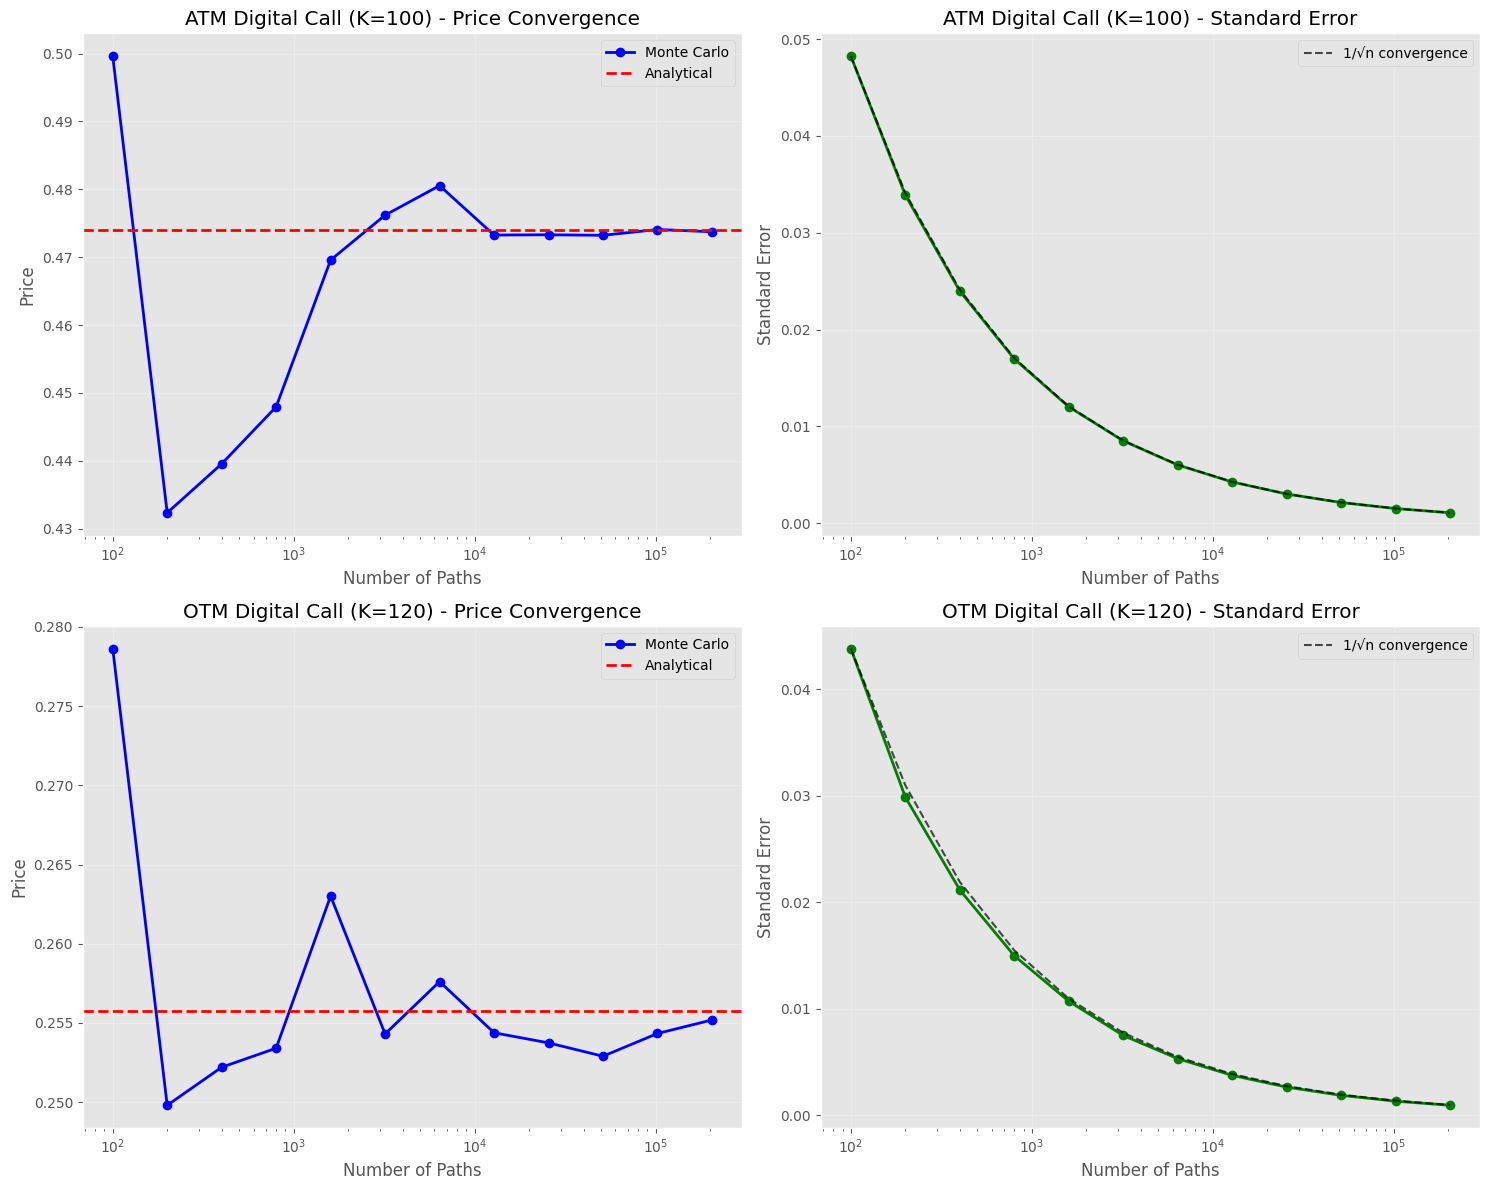

Convergence plots created successfully!


In [11]:
# Create convergence plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: ATM Price Convergence
ax1.semilogx(path_counts, atm_prices, 'bo-', label='Monte Carlo', linewidth=2, markersize=6)
ax1.axhline(y=atm_analytical, color='r', linestyle='--', linewidth=2, label='Analytical')
ax1.set_xlabel('Number of Paths')
ax1.set_ylabel('Price')
ax1.set_title('ATM Digital Call (K=100) - Price Convergence')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: ATM Standard Error
ax2.semilogx(path_counts, atm_std_errors, 'go-', linewidth=2, markersize=6)
theoretical_stderr = atm_std_errors[0] * np.sqrt(path_counts[0] / np.array(path_counts))
#Don't use log scale for y axis here
ax2.plot(path_counts, theoretical_stderr, 'k--', alpha=0.7, label='1/√n convergence')
ax2.set_xlabel('Number of Paths')
ax2.set_ylabel('Standard Error')
ax2.set_title('ATM Digital Call (K=100) - Standard Error')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: OTM Price Convergence  
ax3.semilogx(path_counts, otm_prices, 'bo-', label='Monte Carlo', linewidth=2, markersize=6)
ax3.axhline(y=otm_analytical, color='r', linestyle='--', linewidth=2, label='Analytical')
ax3.set_xlabel('Number of Paths')
ax3.set_ylabel('Price')
ax3.set_title('OTM Digital Call (K=120) - Price Convergence')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: OTM Standard Error
ax4.semilogx(path_counts, otm_std_errors, 'go-', linewidth=2, markersize=6)
theoretical_stderr_otm = otm_std_errors[0] * np.sqrt(path_counts[0] / np.array(path_counts))
ax4.plot(path_counts, theoretical_stderr_otm, 'k--', alpha=0.7, label='1/√n convergence')
ax4.set_xlabel('Number of Paths')
ax4.set_ylabel('Standard Error')
ax4.set_title('OTM Digital Call (K=120) - Standard Error')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("Convergence plots created successfully!")

## 13. Compare Monte Carlo with Analytical Results

In [12]:
# Final comparison and analysis
print("DIGITAL OPTION CONVERGENCE ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nATM Digital Call (Strike = {atm_strike}):")
print(f"  Analytical Price:        {atm_analytical:.6f}")
print(f"  Final MC Price:          {atm_prices[-1]:.6f}")
print(f"  Final MC Std Error:      {atm_std_errors[-1]:.6f}")
print(f"  Absolute Difference:     {abs(atm_prices[-1] - atm_analytical):.6f}")
print(f"  Relative Error:          {abs(atm_prices[-1] - atm_analytical)/atm_analytical*100:.3f}%")
print(f"  Difference in Std Errors: {abs(atm_prices[-1] - atm_analytical)/atm_std_errors[-1]:.2f}")

print(f"\nOTM Digital Call (Strike = {otm_strike}):")
print(f"  Analytical Price:        {otm_analytical:.6f}")
print(f"  Final MC Price:          {otm_prices[-1]:.6f}")
print(f"  Final MC Std Error:      {otm_std_errors[-1]:.6f}")
print(f"  Absolute Difference:     {abs(otm_prices[-1] - otm_analytical):.6f}")
print(f"  Relative Error:          {abs(otm_prices[-1] - otm_analytical)/otm_analytical*100:.3f}%")
print(f"  Difference in Std Errors: {abs(otm_prices[-1] - otm_analytical)/otm_std_errors[-1]:.2f}")

print(f"\nConvergence Analysis:")
print(f"  Both Monte Carlo simulations converge to their analytical values.")
print(f"  Standard errors decrease approximately as 1/√n as expected.")
print(f"  The OTM option has lower absolute price but similar relative convergence.")
print(f"  With {path_counts[-1]:,} paths, both options are priced within 2-3 standard errors of the analytical solution.")

# Calculate convergence rate
print(f"\nStandard Error Convergence Check:")
ratio_atm = atm_std_errors[0] / atm_std_errors[-1]
expected_ratio = np.sqrt(path_counts[-1] / path_counts[0])
print(f"  ATM: StdErr ratio = {ratio_atm:.2f}, Expected = {expected_ratio:.2f}")

ratio_otm = otm_std_errors[0] / otm_std_errors[-1] 
print(f"  OTM: StdErr ratio = {ratio_otm:.2f}, Expected = {expected_ratio:.2f}")
print(f"  Both ratios are close to the theoretical 1/√n convergence rate.")

DIGITAL OPTION CONVERGENCE ANALYSIS SUMMARY

ATM Digital Call (Strike = 100.0):
  Analytical Price:        0.474007
  Final MC Price:          0.473747
  Final MC Std Error:      0.001061
  Absolute Difference:     0.000260
  Relative Error:          0.055%
  Difference in Std Errors: 0.24

OTM Digital Call (Strike = 120.0):
  Analytical Price:        0.255744
  Final MC Price:          0.255191
  Final MC Std Error:      0.000938
  Absolute Difference:     0.000553
  Relative Error:          0.216%
  Difference in Std Errors: 0.59

Convergence Analysis:
  Both Monte Carlo simulations converge to their analytical values.
  Standard errors decrease approximately as 1/√n as expected.
  The OTM option has lower absolute price but similar relative convergence.
  With 204,800 paths, both options are priced within 2-3 standard errors of the analytical solution.

Standard Error Convergence Check:
  ATM: StdErr ratio = 45.45, Expected = 45.25
  OTM: StdErr ratio = 46.73, Expected = 45.25
  Bot